In [910]:
# import os
# import sys
# from pathlib import Path
# import shutil
# import datetime
# import math

# import attrs
# from liblaf import cherries
# from loguru import logger
# from tqdm import tqdm

# # 替换此行
# # sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "../../src")))

# # 方法1：使用当前工作目录
# notebook_dir = os.getcwd()  # 获取当前工作目录
# src_path = os.path.abspath(os.path.join(notebook_dir, "../../src"))
# sys.path.insert(0, src_path)


# import qoc
# import qoc.api as api # pyright: ignore


# db: str = qoc.data_dir("database").as_uri().replace("file://", "lmdb://")


# online: bool = False

# symbols: list[str] = [
#     "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
#     "LINKUSDT", "TRXUSDT", "DOTUSDT", "MATICUSDT", "LTCUSDT", "UNIUSDT", "ATOMUSDT", "ETCUSDT",
#     "ICPUSDT", "APTUSDT", "FILUSDT", "NEARUSDT", "HBARUSDT", "INJUSDT", "OPUSDT", "ARBUSDT",
#     "SUIUSDT", "SEIUSDT", "RENDERUSDT", "TIAUSDT", "FTMUSDT", "EGLDUSDT", "AAVEUSDT", "GALAUSDT",
#     "IMXUSDT", "PEPEUSDT", "SHIBUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT", "PENGUUSDT", "TRUMPUSDT",
#     "POLUSDT", "ENSUSDT", "JUPUSDT", "PYTHUSDT", "ORDIUSDT", "SATOSHIUSDT", "SATSUSDT", "MOVRUSDT",
#     "DYMUSDT", "NOTUSDT", "MAGAUSDT", "SPXUSDT"
# ]



# # symbols: list[str] = ["BTCUSDT", "DOGEUSDT"]
# transaction_fee: float = 0.01  # 交易费用为0.1%
# interval: str = "1m"
# start_date: str = "2024-09-01"
# end_date: str = "2025-08-31"
# output_dir: str = "mmpair-strategy/1m_klines_raw"


# offline_db_path = Path("mmpair-strategy")
# if offline_db_path.exists():
#     # logger.info(f"删除现有数据库文件夹: {offline_db_path}")
#     shutil.rmtree(offline_db_path)


# from offline_fetch import fetch_for_offline
# import arcticdb as adb
# uri = "lmdb://mmpair-strategy"

# ac = adb.Arctic(uri)

# qoc_library = ac.get_library('market', create_if_missing=True)

# fetch_for_offline(symbols, interval, start_date, end_date, output_dir, qoc_library)


In [911]:
from pathlib import Path
import copy
import pandas as pd

output_dir = "mmpair-strategy/1m_klines_raw"
output_path = Path(output_dir)

coins_dict = {}
    
for file in output_path.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        df = pd.read_csv(file, encoding="utf-8")

        df["Close Time"] = df["Close Time"].apply(
            lambda x: x * 1000 + 999 if x < 2000000000000 else x
        )

        df["Close Time"] = pd.to_datetime(df["Close Time"], unit="us")

        df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

        if "Close" not in df.columns or "Close Time" not in df.columns:
            print(f"⚠️ 跳过无 Close 或 Close Time 的文件: {file.name}")
            continue

        df.set_index("Close Time", inplace=True)
        symbol = file.stem.split("_")[0]
        
        if len(df) ==525600:
            coins_dict[symbol] = df
            print(f"Processing symbol: {symbol}, length: {len(df)}")


btc = coins_dict["BTCUSDT"]

HEDGE_LIST = {k: v for k, v in coins_dict.items() if k != "BTCUSDT"}


temp = copy.deepcopy(HEDGE_LIST)

Processing symbol: IMXUSDT, length: 525600
Processing symbol: SOLUSDT, length: 525600
Processing symbol: NOTUSDT, length: 525600
Processing symbol: BONKUSDT, length: 525600
Processing symbol: LTCUSDT, length: 525600
Processing symbol: ORDIUSDT, length: 525600
Processing symbol: SUIUSDT, length: 525600
Processing symbol: JUPUSDT, length: 525600
Processing symbol: NEARUSDT, length: 525600
Processing symbol: ATOMUSDT, length: 525600
Processing symbol: APTUSDT, length: 525600
Processing symbol: GALAUSDT, length: 525600
Processing symbol: ARBUSDT, length: 525600
Processing symbol: TRXUSDT, length: 525600
Processing symbol: BNBUSDT, length: 525600
Processing symbol: DOTUSDT, length: 525600
Processing symbol: FILUSDT, length: 525600
Processing symbol: ETCUSDT, length: 525600
Processing symbol: RENDERUSDT, length: 525600
Processing symbol: FLOKIUSDT, length: 525600
Processing symbol: BTCUSDT, length: 525600
Processing symbol: LINKUSDT, length: 525600
Processing symbol: SHIBUSDT, length: 525600

In [912]:
HEDGE_LIST = temp

In [913]:

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random

In [914]:
len(HEDGE_LIST.keys())

42

In [915]:

# 截取前半段（会真正修改 HEDGE_LIST 中的每个 DataFrame）
half_length = 525600//6

i=1

for name, df in HEDGE_LIST.items():
#     HEDGE_LIST[name] = df.iloc[(i-1)*half_length:i*half_length]    
    
# btc = btc.iloc[(i-1)*half_length:i*half_length]    
    HEDGE_LIST[name] = df.iloc[0*half_length:4*half_length]    
    
btc = btc.iloc[0*half_length:4*half_length]    




In [916]:

BULLET_SIZE = 1000
INITIAL = 10000



FORWARD_WINDOW = 300
BACK_WINDOW = 900



MIN_POR = 0.05


In [917]:
back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW
bullet_size = BULLET_SIZE


btc_close = deque(btc['Close'][:back_window], maxlen=back_window)
coin_closes = {name: deque(df['Close'][:back_window], maxlen=back_window) for name, df in HEDGE_LIST.items()}

btc_volume = deque(btc['Volume'][:back_window], maxlen=back_window)
coin_volumes = {name: deque(df['Volume'][:back_window], maxlen=back_window) for name, df in HEDGE_LIST.items()}

mkt_idx_1 = deque(np.array([0]*back_window), maxlen=back_window)
coin_vwaps = {name: deque(np.array([0]*back_window), maxlen=back_window) for name, df in HEDGE_LIST.items()}

mkt_idx_2 = deque(np.array([0]*back_window), maxlen=back_window)

mkt_idx_3 = deque(np.array([0]*(back_window-1)), maxlen=back_window-1)

cmi_dict = {}


time_range = range(back_window, len(btc) - forward_window)

num = 0
revenues = []
stats_1 = []
stats_2 = []
stats_3 = []
stats_4 = []
stats_5 = []
stats_6 = []
stats_7 = []



sum_of_theta_price = 0

for i, t in tqdm(enumerate(time_range), total=len(time_range), desc="Sliding window"):

 

    btc_close.append(btc['Close'].iloc[t])
    btc_volume.append(btc['Volume'].iloc[t])

        # CMI
    arr = np.array(btc_close)

    diff = np.diff(arr)
    cmi_btc = (arr[-1] - arr[0]) / np.sum(np.abs(diff))*100

    if i>=back_window:
        vwap = np.sum(np.array(btc_close)*np.array(btc_volume))/np.sum(np.array(btc_volume))
        mkt_idx_1.append(vwap)
        mkt_idx_2.append(0)
        mkt_idx_3.append(0)

    corr_array = []

    coef_records = {name: [] for name in HEDGE_LIST.keys()}

    for name, df in HEDGE_LIST.items():
        coin_closes[name].append(df['Close'].iloc[t])
        coin_volumes[name].append(df['Volume'].iloc[t])

        if i>=back_window:
            vwap = np.sum(np.array(coin_closes[name])*np.array(coin_volumes[name]))/np.sum(np.array(coin_volumes[name]))
            coin_vwaps[name].append(vwap)
            mkt_idx_2[-1] += (np.array(coin_closes[name])[-1]*np.array(coin_volumes[name])[-1])

            growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2]) / np.array(coin_closes[name])[-2]
            if abs(growth)>abs(mkt_idx_3[-1]):
                mkt_idx_3[-1] = growth


    mkt_idx_1_diff = np.diff(mkt_idx_1)
    mkt_idx_2_diff = np.diff(mkt_idx_2)

    


    # if i%1000 ==0:
    #     plt.figure(figsize=(12, 6))
    #     ax1 = plt.subplot(3, 1, 1)
    #     ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    #     ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    #     ax1.plot(mkt_idx_1_diff, label='Market Index 1 (VWAP)', color='blue')
    #     ax2.plot(mkt_idx_2_diff, label='Market Index 2 (Volume Weighted Close)', color='orange')
    #     for name, vwap in coin_vwaps.items():
    #         normalized_vwap = np.array(vwap)/vwap[0]*100
    #         ax3.plot(np.diff(normalized_vwap), label=f'{name} VWAP', alpha=0.3)
    #     ax1.set_title('Market Index 1 (VWAP)')
    #     ax2.set_title('Market Index 2 (Volume Weighted Close)')
    #     ax3.set_title('Coin VWAPs')
    #     plt.show()
    #     plt.close()



    if i >= 2*back_window:

        for name, df in HEDGE_LIST.items():
            if i%forward_window == 0:

                # CMI
                arr = np.array(coin_closes[name]).reshape(-1, 1).flatten()

                diff = np.diff(arr)
                cmi = (arr[-1] - arr[0]) / np.sum(np.abs(diff))*100
                cmi_dict[name] = cmi

                coin_vwap_diff = np.diff(np.array(coin_vwaps[name]))


                # LINEAR 
                y_0 = np.array(coin_closes[name]).reshape(-1, 1)
                X_btc = np.array(btc_close).reshape(-1, 1)
                model_btc = LinearRegression(fit_intercept=True)
                model_btc.fit(X_btc, y_0)
                coef_btc = model_btc.coef_[0][0]
                y_pred_btc = model_btc.predict(X_btc)
                cor = model_btc.score(X_btc, y_0)

                residual_btc = (y_0 - y_pred_btc)
                y_ret = y_0[1:] / y_0[:-1] - 1
                x_ret = X_btc[1:] / X_btc[:-1] - 1


                # LINEAR 1
                # y = np.array(coin_vwap_diff).reshape(-1, 1)
                y = np.array(np.diff(arr)).reshape(-1, 1)
                X = np.array(mkt_idx_1_diff).reshape(-1, 1)
                model = LinearRegression(fit_intercept=True)
                model.fit(X, y)
                coef_1 = model.coef_[0][0]
                cor_1 = model.score(X, y)

                # LINEAR 2
                # y = np.array(coin_vwap_diff).reshape(-1, 1)
                y = np.array(np.diff(arr)).reshape(-1, 1)
                X = np.array(mkt_idx_2_diff).reshape(-1, 1)
                model = LinearRegression(fit_intercept=True)
                model.fit(X, y)
                coef_2 = model.coef_[0][0]
                cor_2 = model.score(X, y)


                # LINEAR 2
                # y = np.array(coin_vwap_diff).reshape(-1, 1)
                y = np.array(np.diff(arr)).reshape(-1, 1)
                X = np.array(mkt_idx_3).reshape(-1, 1)
                model = LinearRegression(fit_intercept=True)
                model.fit(X, y)
                coef_3 = model.coef_[0][0]
                cor_3 = model.score(X, y)




                # RETURN
                coef_records[name] = {
                    'coef_0': coef_btc*100000,
                    'coef_1': coef_1*100000,
                    'coef_2': coef_2*100000,                
                    'coef_3': coef_3*100000,                
                    # 'correlation': np.corrcoef(X_btc.flatten(), y_0.flatten())[0, 1],
                    'correlation': cor,
                    'correlation_1': cor_1,
                    'correlation_2': cor_2,
                    'correlation_3': cor_3,
                    'residual': residual_btc[-1, 0],
                    'cmi': cmi,
                }



        if i % forward_window == 0:
            # print(f"\n=== Step {i}: Coefficients collected for all coins ===")
            # === 将 coef_records 转为 DataFrame ===
            coef_df = pd.DataFrame.from_dict(coef_records, orient='index')  # index=coin

            # === 确保 residual 列是 float ===
            coef_df['residual'] = coef_df['residual'].astype(float)
            coef_df['cmi'] = coef_df['cmi'].astype(float)
            coef_df['correlation'] = coef_df['correlation'].astype(float)
            coef_df['coef_0'] = coef_df['coef_0']
            coef_df['coef_1'] = coef_df['coef_1']
            coef_df['coef_2'] = coef_df['coef_2']
            coef_df['coef_3'] = coef_df['coef_3']
            coef_df['rsd_norm'] = coef_df['residual']/coef_df['coef_0']
            

            # print(coef_df)


            sharpe = coef_df['cmi'].mean() / coef_df['cmi'].std()
            sharpe_rsd_norm = coef_df['rsd_norm'].mean() / coef_df['rsd_norm'].std()

            k=10

            # 按 correlation 降序取前 k 个
            topk_df = coef_df.sort_values(by='correlation', ascending=False).iloc[:k].copy()
            if len(topk_df) < k:
                print(f"Warning: only {len(topk_df)} coins available, k={k}")
            names = topk_df.index.tolist()

            residuals = topk_df['residual'].values.astype(float)  # shape (k,)
            coef0 = topk_df['coef_0'].values.astype(float)
            coef1 = topk_df['coef_1'].values.astype(float)
            coef2 = topk_df['coef_2'].values.astype(float)
            coef3 = topk_df['coef_3'].values.astype(float)

            prices = np.array([HEDGE_LIST[n]['Close'].iloc[t] for n in names], dtype=float)

            k = len(prices)

            # 原目标函数 c^T x
            c_x = residuals 

            # 我们引入新的变量 y_i 表示 |x_i * prices_i|
            # 所以变量总数 = k (x_i) + k (y_i)
            c = np.concatenate([c_x, np.zeros(k)])  # 目标函数只作用在 x 上

            # 线性约束 A_eq x = b_eq
            A_eq = np.hstack([np.vstack([coef0, coef1, coef2]), np.zeros((3, k))])
            b_eq = np.zeros(3)

            # --- 绝对值约束部分 ---
            # 对于每个 i: y_i >=  prices_i * x_i
            #             y_i >= -prices_i * x_i
            #             sum(y_i) <= 1000
            A_ub = []
            b_ub = []

            for i in range(k):
                row_pos = np.zeros(2 * k)
                row_pos[i] = prices[i]
                row_pos[k + i] = -1
                A_ub.append(row_pos)
                b_ub.append(0.0)

                row_neg = np.zeros(2 * k)
                row_neg[i] = -prices[i]
                row_neg[k + i] = -1
                A_ub.append(row_neg)
                b_ub.append(0.0)

            # sum(y_i) <= 1000
            row_sum = np.zeros(2 * k)
            row_sum[k:] = 1.0
            A_ub.append(row_sum)
            b_ub.append(1000.0)

            A_ub = np.array(A_ub)
            b_ub = np.array(b_ub)

            # 变量边界
            bounds = [(-np.inf, np.inf)] * k + [(0, np.inf)] * k

            # 求解线性规划
            res = linprog(c=c, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')


            if res.success and topk_df['correlation'].mean()>0.7 and -5<cmi_btc<5:
            # if res.success:
                theta = res.x[:k] 
                objective_value = -res.fun  # 因为我们最小化 -residual，所以真实的 residual_sum = -res.fun
                # 构建结果 DataFrame
                df = pd.DataFrame({
                    'name': names,
                    'coef_0': coef0,
                    'coef_1': coef1,
                    'coef_2': coef2,
                    'coef_3': coef3,
                    'price': prices,
                    'cmi': topk_df['cmi'].values,
                    'correlation': topk_df['correlation'].values,
                    'correlation_1': topk_df['correlation_1'].values,
                    'correlation_2': topk_df['correlation_2'].values,
                    'correlation_3': topk_df['correlation_3'].values,
                    'residual': residuals,
                    'theta': theta,
                    'theta*residual': theta * residuals* prices,
                    'theta*price': theta * prices,
                })

                # print(df)


                sum_of_theta_price += sum(abs(theta * prices))
                number_of_neg_res = sum(df['residual']<0)


                # if objective_value < -0: and min(df['correlation'])>0.6 and sharpe<0.5 and sharpe>-0.5:

                num+=1    
                stats_1.append(df['correlation'].mean())
                stats_2.append(df['correlation_1'].mean())
                stats_3.append(df['correlation_2'].mean())
                stats_4.append(df['correlation_3'].mean())
                # stats_4.append(sharpe_rsd_norm)
                stats_5.append(sharpe)
                stats_6.append(cmi_btc)
                stats_7.append(objective_value)


                corr_array = np.array(corr_array)



                stop_loss_ratio = 0.02  # 2% 止损比例
                revenue_path = np.zeros(forward_window)
                revenue = 0.0

                # === 构建逐步revenue序列 ===
                for idx, row in df.iterrows():
                    name = row['name']
                    theta_value = row['theta']
                    price = HEDGE_LIST[name]['Close'].iloc[t]

                    # 对应币种未来价格路径
                    future_prices = HEDGE_LIST[name]['Close'].iloc[t:t + forward_window]
                    # 单币种逐步收益
                    future_revenues = (future_prices - price) * theta_value
                    # 累加到组合
                    revenue_path += future_revenues.values  # 确保是numpy array

                # === 遍历止损逻辑 ===
                stopped_revenue = revenue_path[-1]  # 默认没止损时最后一个
                for r in revenue_path:
                    if abs(r) > 1000 * stop_loss_ratio:
                        stopped_revenue = r
                        break  # 触发止损
                # for r in revenue_path:
                #     if r < -100 * stop_loss_ratio or r > 100 * stop_loss_ratio:
                #         stopped_revenue = r
                #         break  # 触发止损
                else:
                    stopped_revenue = revenue_path[-1]  # 没触发止损

                revenues.append(stopped_revenue)
        if (i-1)%(forward_window)==0:

            import numpy as np
            import pandas as pd
            import matplotlib.pyplot as plt

            # 假设 revenue_series 是 pandas Series 或 numpy array
            # 示例：
            revenue_series = pd.Series(revenues)

            # 1️⃣ 累积收益
            cumulative_revenue = np.cumsum(revenue_series)

            # 2️⃣ 绘图
            plt.figure(figsize=(10, 5))
            plt.plot(cumulative_revenue, label='Cumulative Revenue', color='steelblue', linewidth=1.5)
            plt.title("Cumulative Revenue Over Time", fontsize=14, fontweight='bold')
            plt.xlabel("Time Index")
            plt.ylabel("Cumulative Revenue")
            plt.grid(alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.savefig("cumulative_revenue.png", dpi=300)
            plt.close()

            if sum_of_theta_price!=0:
                print(f"🟢 Step {i}, cumulative {sum(revenues):.2f}, average {sum(revenues)/sum_of_theta_price:.8f}")
            # else:
            #     print("⚠️ 线性规划求解失败:", res.message)






Sliding window:   0%|          | 0/349200 [00:00<?, ?it/s]

Sliding window:   1%|          | 2125/349200 [00:13<1:20:29, 71.87it/s]

🟢 Step 2101, cumulative -5.72, average -0.00572470


Sliding window:   1%|          | 2417/349200 [00:16<1:21:46, 70.67it/s]

🟢 Step 2401, cumulative -4.98, average -0.00249220


...

Sliding window: 100%|█████████▉| 348615/349200 [1:02:16<00:08, 66.57it/s] 

🟢 Step 348601, cumulative 157.39, average 0.00028825


Sliding window: 100%|█████████▉| 348923/349200 [1:02:20<00:03, 74.46it/s] 

🟢 Step 348901, cumulative 157.39, average 0.00028825


Sliding window: 100%|██████████| 349200/349200 [1:02:22<00:00, 93.30it/s] 


546

In [926]:
stats = stats_1
# stats = stats_2
# stats = stats_3
# stats = stats_4
# stats = stats_5
# stats = stats_6
# stats = stats_7

In [927]:
# stats = np.log(np.array(stats))

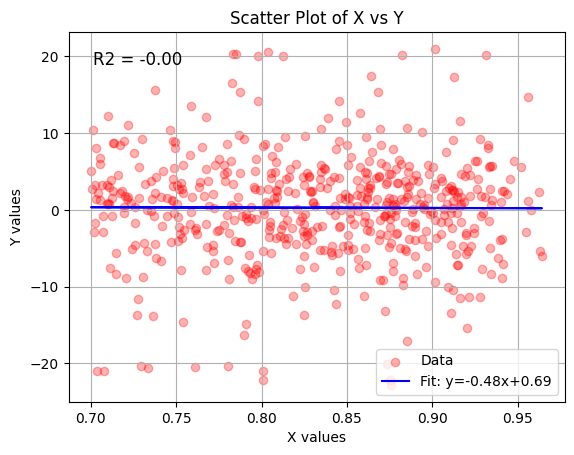

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_1011/3103165630.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()


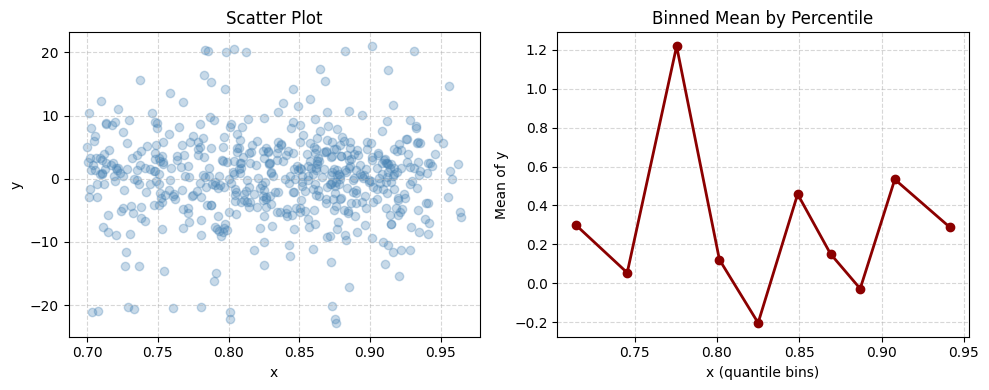

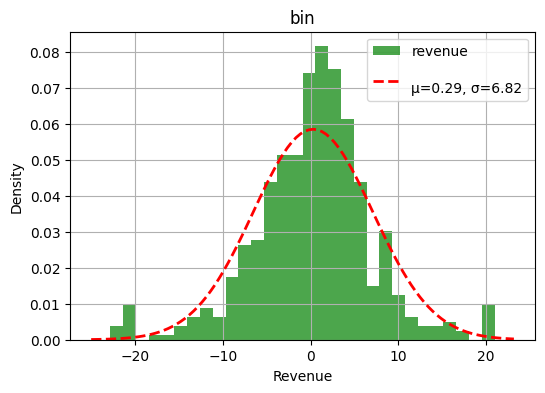

In [928]:
import matplotlib.pyplot as plt
import numpy as np


# 假设 stats_1 和 revenues 已经定义为一维数组或列表
x = np.array(stats)
y = np.array(revenues)

# 线性回归
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# 相关系数
r = np.corrcoef(x, y)[0, 1]

plt.scatter(x, y, color='red', alpha=0.3, label='Data')
plt.plot(x, y_pred, color='blue', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter Plot of X vs Y")
plt.grid(True)
plt.legend()

# 在图上显示相关系数
plt.text(0.05, 0.95, f'R2 = {r:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()
plt.close()

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x = np.array(stats)
y = np.array(revenues)

# === 按百分比分箱 ===
n_bins = 10
quantiles = np.linspace(0, 1, n_bins + 1)
bins = np.quantile(x, quantiles)  # 按x的分位数分箱

# 为避免重复的边界（在x有重复值时）
bins = np.unique(bins)

bin_labels = pd.cut(x, bins=bins, include_lowest=True)
bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()
bin_centers = [(interval.left + interval.right) / 2 for interval in bin_means.index]

# === 两个子图（不共享 y） ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# 左边：散点图
ax1.scatter(x, y, alpha=0.3, color='steelblue')
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Scatter Plot")
ax1.grid(True, linestyle='--', alpha=0.5)

# 右边：分箱均值图
ax2.plot(bin_centers, bin_means.values, color='darkred', marker='o', lw=2)
ax2.set_xlabel("x (quantile bins)")
ax2.set_ylabel("Mean of y")
ax2.set_title("Binned Mean by Percentile")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
plt.close()


import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# 假设 y 是收益率数组
mu, std = norm.fit(y)  # 拟合正态分布，得到均值和标准差

plt.figure(figsize=(6, 4))
count, bins, ignored = plt.hist(y, bins=30, color='green', alpha=0.7, density=True, label='revenue')

# 拟合的正态分布曲线
xmin, xmax = plt.xlim()
x_fit = np.linspace(xmin, xmax, 100)
p_fit = norm.pdf(x_fit, mu, std)
plt.plot(x_fit, p_fit, 'r--', linewidth=2, label=f'\nμ={mu:.2f}, σ={std:.2f}')

plt.xlabel("Revenue")
plt.ylabel("Density")
plt.title("bin")
plt.grid(True)
plt.legend()
plt.show()

In [929]:
# revenues

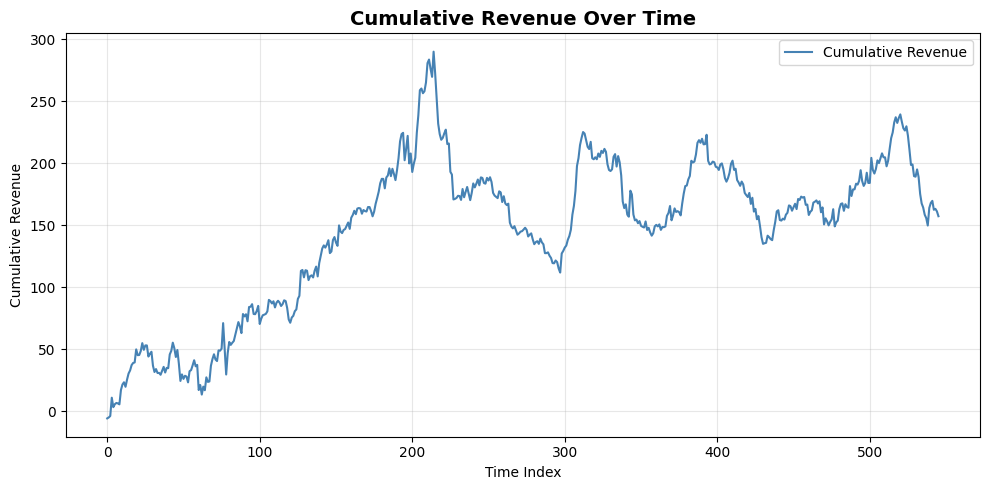

In [930]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 假设 revenue_series 是 pandas Series 或 numpy array
# 示例：
revenue_series = pd.Series(revenues)

# 1️⃣ 累积收益
cumulative_revenue = np.cumsum(revenue_series)

# 2️⃣ 绘图
plt.figure(figsize=(10, 5))
plt.plot(cumulative_revenue, label='Cumulative Revenue', color='steelblue', linewidth=1.5)
plt.title("Cumulative Revenue Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Time Index")
plt.ylabel("Cumulative Revenue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_revenue.png", dpi=300)


In [931]:
revenue_series.describe()

count    546.000000
mean       0.288254
std        6.823928
min      -22.806197
25%       -3.308031
50%        0.736709
75%        4.025852
max       20.983148
dtype: float64